# Convolutional Neural Networks

# Importar Librerías

In [155]:
import numpy as np
import os
import re
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [156]:
import keras
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from keras.models import Sequential,Model
from tensorflow.keras.layers import Input
from keras.layers import Dense, Dropout, Flatten
#from keras.layers import Conv2D, MaxPooling2D
#from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    BatchNormalization, SeparableConv2D, MaxPooling2D, Activation, Flatten, Dropout, Dense, Conv2D
)
from keras.layers import LeakyReLU

# Cargar set de Imágenes

In [157]:
dirname = os.path.join(os.getcwd(),'/media/glowar23/Disco2/IA/cnn/sportimages/sportimages')
imgpath = dirname + os.sep 

images = []
directories = []
dircount = []
prevRoot=''
cant=0

print("leyendo imagenes de ",imgpath)

for root, dirnames, filenames in os.walk(imgpath):
    for filename in filenames:
        if re.search("\.(jpg|jpeg|png|bmp|tiff)$", filename):
            cant=cant+1
            filepath = os.path.join(root, filename)
            image = plt.imread(filepath)
            if(len(image.shape)==3):
                
                images.append(image)
            b = "Leyendo..." + str(cant)
            print (b, end="\r")
            if prevRoot !=root:
                print(root, cant)
                prevRoot=root
                directories.append(root)
                dircount.append(cant)
                cant=0
dircount.append(cant)

dircount = dircount[1:]
dircount[0]=dircount[0]+1
print('Directorios leidos:',len(directories))
print("Imagenes en cada directorio", dircount)
print('suma Total de imagenes en subdirs:',sum(dircount))

<>:14: SyntaxWarning: invalid escape sequence '\.'
<>:14: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_10766/2709275032.py:14: SyntaxWarning: invalid escape sequence '\.'
  if re.search("\.(jpg|jpeg|png|bmp|tiff)$", filename):


leyendo imagenes de  /media/glowar23/Disco2/IA/cnn/sportimages/sportimages/
/media/glowar23/Disco2/IA/cnn/sportimages/sportimages/americano 1
/media/glowar23/Disco2/IA/cnn/sportimages/sportimages/basket 9348
/media/glowar23/Disco2/IA/cnn/sportimages/sportimages/beisball 8823
/media/glowar23/Disco2/IA/cnn/sportimages/sportimages/boxeo 7752
/media/glowar23/Disco2/IA/cnn/sportimages/sportimages/ciclismo 7125
/media/glowar23/Disco2/IA/cnn/sportimages/sportimages/f1 7533
/media/glowar23/Disco2/IA/cnn/sportimages/sportimages/futbol 5053
/media/glowar23/Disco2/IA/cnn/sportimages/sportimages/golf 7617
/media/glowar23/Disco2/IA/cnn/sportimages/sportimages/natacion 9768
/media/glowar23/Disco2/IA/cnn/sportimages/sportimages/tenis 5172
Directorios leidos: 10
Imagenes en cada directorio [9349, 8823, 7752, 7125, 7533, 5053, 7617, 9768, 5172, 8936]
suma Total de imagenes en subdirs: 77128


# Creamos las etiquetas

In [158]:
labels=[]
indice=0
for cantidad in dircount:
    for i in range(cantidad):
        labels.append(indice)
    indice=indice+1
print("Cantidad etiquetas creadas: ",len(labels))


Cantidad etiquetas creadas:  77128


In [159]:
deportes=[]
indice=0
for directorio in directories:
    name = directorio.split(os.sep)
    print(indice , name[len(name)-1])
    deportes.append(name[len(name)-1])
    indice=indice+1

0 americano
1 basket
2 beisball
3 boxeo
4 ciclismo
5 f1
6 futbol
7 golf
8 natacion
9 tenis


In [160]:
y = np.array(labels)
X = np.array(images, dtype=np.uint8) #convierto de lista a numpy



# Find the unique numbers from the train labels
classes = np.unique(y)
nClasses = len(classes)
print('Total number of outputs : ', nClasses)
print('Output classes : ', classes)

Total number of outputs :  10
Output classes :  [0 1 2 3 4 5 6 7 8 9]


# Creamos Sets de Entrenamiento y Test

In [161]:
train_X,test_X,train_Y,test_Y = train_test_split(X,y,test_size=0.2)
print('Training data shape : ', train_X.shape, train_Y.shape)
print('Testing data shape : ', test_X.shape, test_Y.shape)

Training data shape :  (61702, 21, 28, 3) (61702,)
Testing data shape :  (15426, 21, 28, 3) (15426,)


Text(0.5, 1.0, 'Ground Truth : 5')

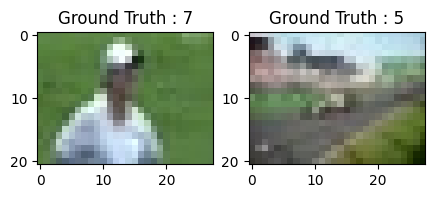

In [162]:
plt.figure(figsize=[5,5])

# Display the first image in training data
plt.subplot(121)
plt.imshow(train_X[0,:,:], cmap='gray')
plt.title("Ground Truth : {}".format(train_Y[0]))

# Display the first image in testing data
plt.subplot(122)
plt.imshow(test_X[0,:,:], cmap='gray')
plt.title("Ground Truth : {}".format(test_Y[0]))

# Preprocesamos las imagenes

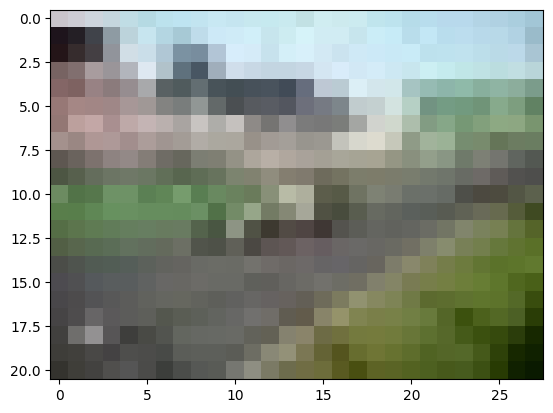

In [163]:
train_X = train_X.astype('float32')
test_X = test_X.astype('float32')
train_X = train_X/255.
test_X = test_X/255.
plt.imshow(test_X[0,:,:])

## Hacemos el One-hot Encoding para la red

In [164]:
# Change the labels from categorical to one-hot encoding
train_Y_one_hot = to_categorical(train_Y)
test_Y_one_hot = to_categorical(test_Y)

# Display the change for category label using one-hot encoding
print('Original label:', train_Y[0])
print('After conversion to one-hot:', train_Y_one_hot[0])

Original label: 7
After conversion to one-hot: [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]


# Creamos el Set de Entrenamiento y Validación

In [165]:
#Mezclar todo y crear los grupos de entrenamiento y testing
train_X,valid_X,train_label,valid_label = train_test_split(train_X, train_Y_one_hot, test_size=0.2, random_state=13)

In [166]:
print(train_X.shape,valid_X.shape,train_label.shape,valid_label.shape)

(49361, 21, 28, 3) (12341, 21, 28, 3) (49361, 10) (12341, 10)


# Creamos el modelo de CNN

In [167]:
#declaramos variables con los parámetros de configuración de la red
INIT_LR = 1e-3 # Valor inicial de learning rate. El valor 1e-3 corresponde con 0.001
epochs = 20 # Cantidad de iteraciones completas al conjunto de imagenes de entrenamiento
batch_size = 64 # cantidad de imágenes que se toman a la vez en memoria

In [168]:
sport_model = Sequential()
sport_model.add(Conv2D(32, kernel_size=(3, 3),activation='linear',padding='same',input_shape=(21,28,3)))
sport_model.add(LeakyReLU(alpha=0.1))
sport_model.add(MaxPooling2D((2, 2),padding='same'))
sport_model.add(Dropout(0.5))


sport_model.add(Flatten())
sport_model.add(Dense(32, activation='linear'))
sport_model.add(LeakyReLU(alpha=0.1))
sport_model.add(Dropout(0.5))
sport_model.add(Dense(nClasses, activation='softmax'))

/media/glowar23/Disco2/IA/cnn/venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/media/glowar23/Disco2/IA/cnn/venv/lib/python3.12/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [169]:
sport_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 21, 28, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 21, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 11, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 11, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 4928)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │       157,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_11 (LeakyReLU)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 158,954 (620.91 KB)

 Trainable params: 158,954 (620.91 KB)

 Non-trainable params: 0 (0.00 B)

In [170]:
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=INIT_LR,
    decay_steps=100,
    decay_rate=0.96
)

sport_model.compile(
    loss=keras.losses.categorical_crossentropy,
    optimizer=tf.keras.optimizers.SGD(learning_rate=lr_schedule),
    metrics=['accuracy']
)

# Entrenamos el modelo: Aprende a clasificar imágenes

In [171]:
# este paso puede tomar varios minutos, dependiendo de tu ordenador, cpu y memoria ram libre
sport_train = sport_model.fit(train_X, train_label, batch_size=batch_size,epochs=epochs,verbose=1,validation_data=(valid_X, valid_label))

Epoch 1/20
 37/772 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.0912 - loss: 2.3722

E0000 00:00:1774279679.676057   10766 meta_optimizer.cc:966] remapper failed: INVALID_ARGUMENT: Mutation::Apply error: fanout 'StatefulPartitionedCall/gradient_tape/sequential_5_1/leaky_re_lu_10_1/LeakyRelu/LeakyReluGrad' exist for missing node 'StatefulPartitionedCall/sequential_5_1/conv2d_5_1/BiasAdd'.


772/772 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.1648 - loss: 2.2528 - val_accuracy: 0.3688 - val_loss: 2.1504
Epoch 2/20
772/772 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2287 - loss: 2.1463 - val_accuracy: 0.4426 - val_loss: 2.0332
Epoch 3/20
772/772 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2667 - loss: 2.0671 - val_accuracy: 0.4488 - val_loss: 1.9298
Epoch 4/20
772/772 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2961 - loss: 2.0006 - val_accuracy: 0.5011 - val_loss: 1.8601
Epoch 5/20
772/772 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3155 - loss: 1.9565 - val_accuracy: 0.5368 - val_loss: 1.8108
Epoch 6/20
772/772 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3297 - loss: 1.9267 - val_accuracy: 0.5471 - val_loss: 1.7759
Epoch 7/20
772/772 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3364 - loss: 1.9050 - val_accuracy: 0.5547 - val_loss: 1.7505
Epoch 8/20
772/772 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3474 - loss: 1.8845 - val_accuracy: 0.5543 - val_

In [172]:
# guardamos la red, para reutilizarla en el futuro, sin tener que volver a entrenar
sport_model.save("/media/glowar23/Disco2/IA/cnn/sport_model.h5")

# Evaluamos la red

In [173]:
test_eval = sport_model.evaluate(test_X, test_Y_one_hot, verbose=1)

483/483 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5749 - loss: 1.6872


In [174]:
print('Test loss:', test_eval[0])
print('Test accuracy:', test_eval[1])

Test loss: 1.687178134918213
Test accuracy: 0.5748735666275024


In [175]:
sport_train.history

{'accuracy': [0.1648467481136322,
  0.22874334454536438,
  0.26672878861427307,
  0.29606369137763977,
  0.31553250551223755,
  0.3296934962272644,
  0.33643969893455505,
  0.3474200367927551,
  0.3479264974594116,
  0.35546281933784485,
  0.3543080687522888,
  0.3597171902656555,
  0.35779258608818054,
  0.3591296672821045,
  0.36196592450141907,
  0.36218878626823425,
  0.3623711168766022,
  0.3612973690032959,
  0.3631206750869751,
  0.360547810792923],
 'loss': [2.252750873565674,
  2.1462934017181396,
  2.067108154296875,
  2.000609874725342,
  1.9564592838287354,
  1.92672860622406,
  1.9049689769744873,
  1.8845458030700684,
  1.8760697841644287,
  1.8668031692504883,
  1.8607515096664429,
  1.8565882444381714,
  1.8567426204681396,
  1.8508055210113525,
  1.84956955909729,
  1.8465546369552612,
  1.846255898475647,
  1.8452285528182983,
  1.8441638946533203,
  1.8500932455062866],
 'val_accuracy': [0.3687707781791687,
  0.44258973002433777,
  0.44882911443710327,
  0.5010939240

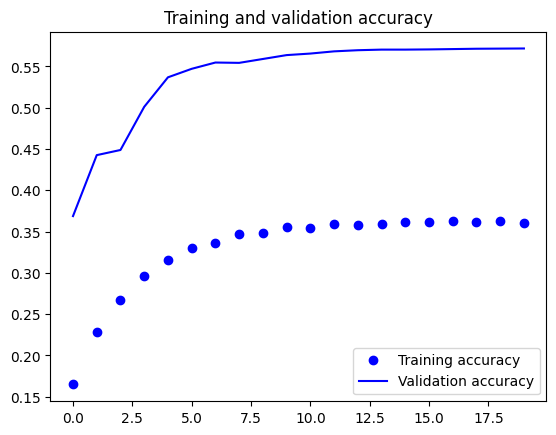

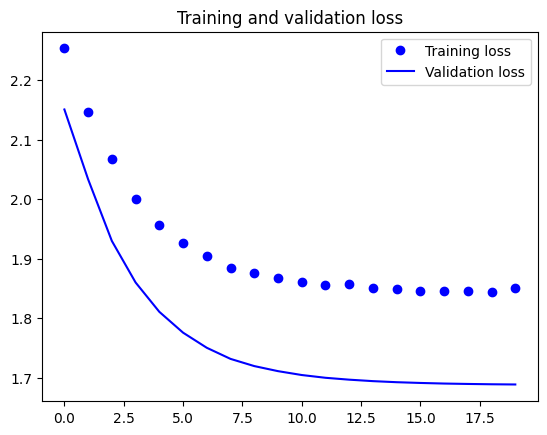

In [176]:
accuracy = sport_train.history['accuracy']
val_accuracy = sport_train.history['val_accuracy']
loss = sport_train.history['loss']
val_loss = sport_train.history['val_loss']
epochs = range(len(accuracy))
plt.plot(epochs, accuracy, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracy, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

In [177]:
predicted_classes2 = sport_model.predict(test_X)

483/483 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [178]:
predicted_classes=[]
for predicted_sport in predicted_classes2:
    predicted_classes.append(predicted_sport.tolist().index(max(predicted_sport)))
predicted_classes=np.array(predicted_classes)

In [179]:
predicted_classes.shape, test_Y.shape

((15426,), (15426,))

# Aprendamos de los errores: Qué mejorar

Found 8868 correct labels


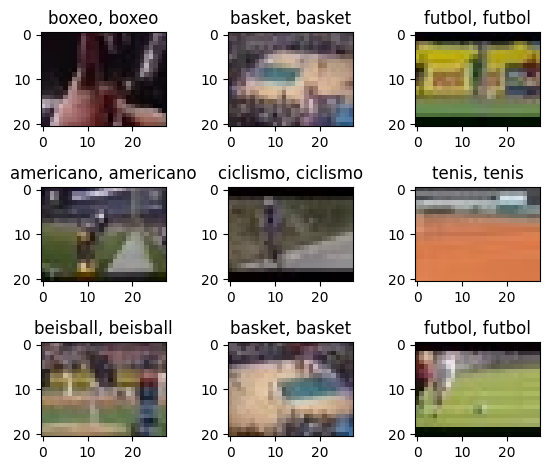

In [180]:
correct = np.where(predicted_classes==test_Y)[0]
print("Found %d correct labels" % len(correct))
for i, correct in enumerate(correct[0:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(test_X[correct].reshape(21,28,3), cmap='gray', interpolation='none')
    plt.title("{}, {}".format(deportes[predicted_classes[correct]],
                                                    deportes[test_Y[correct]]))

    plt.tight_layout()

Found 6558 incorrect labels


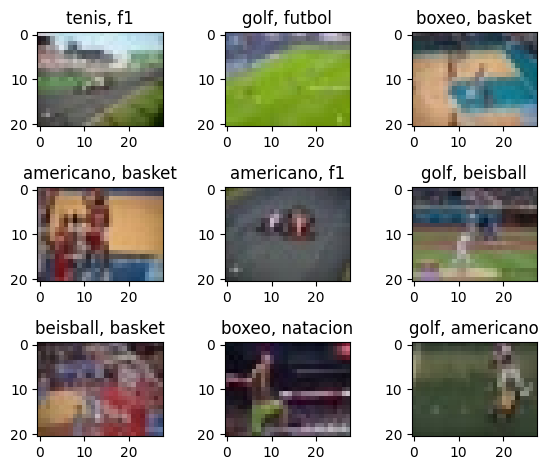

In [181]:
incorrect = np.where(predicted_classes!=test_Y)[0]
print("Found %d incorrect labels" % len(incorrect))
for i, incorrect in enumerate(incorrect[0:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(test_X[incorrect].reshape(21,28,3), cmap='gray', interpolation='none')
    plt.title("{}, {}".format(deportes[predicted_classes[incorrect]],
                                                    deportes[test_Y[incorrect]]))
    plt.tight_layout()

In [182]:
target_names = ["Class {}".format(i) for i in range(nClasses)]
print(classification_report(test_Y, predicted_classes, target_names=target_names))

              precision    recall  f1-score   support

     Class 0       0.37      0.23      0.28      1877
     Class 1       0.72      0.29      0.41      1706
     Class 2       0.42      0.39      0.41      1537
     Class 3       0.58      0.77      0.66      1426
     Class 4       0.87      0.99      0.93      1486
     Class 5       0.00      0.00      0.00       976
     Class 6       0.83      0.59      0.69      1584
     Class 7       0.39      0.64      0.48      1969
     Class 8       0.92      0.75      0.82      1030
     Class 9       0.54      1.00      0.70      1835

    accuracy                           0.57     15426
   macro avg       0.56      0.56      0.54     15426
weighted avg       0.56      0.57      0.54     15426



/media/glowar23/Disco2/IA/cnn/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/media/glowar23/Disco2/IA/cnn/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/media/glowar23/Disco2/IA/cnn/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c